In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


In [31]:
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
holidays = pd.read_csv('holidays_events.csv')
train.head()
train.info()
train.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [32]:
train['date'] = pd.to_datetime(train['date'])
train.isnull().sum()


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

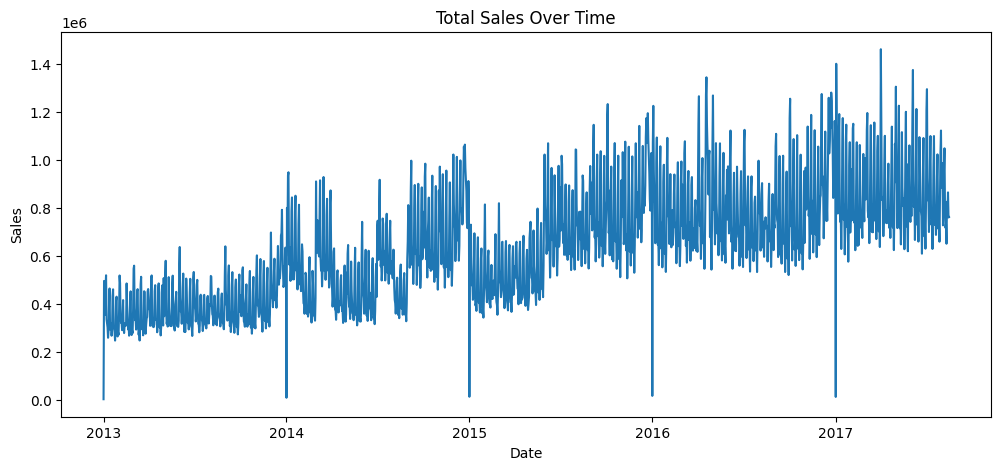

In [33]:
daily_sales = train.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


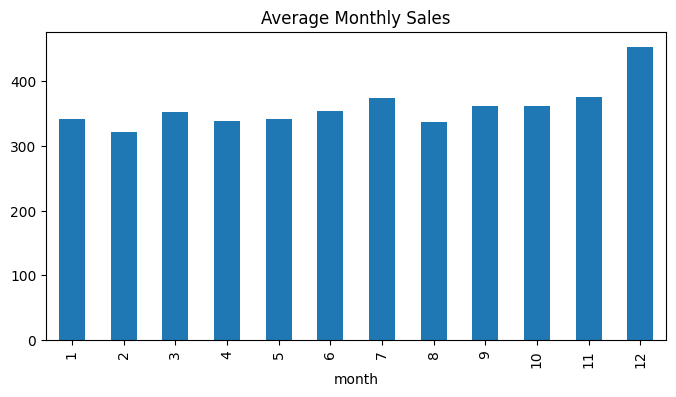

In [34]:
train['month'] = train['date'].dt.month
monthly_sales = train.groupby('month')['sales'].mean()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()


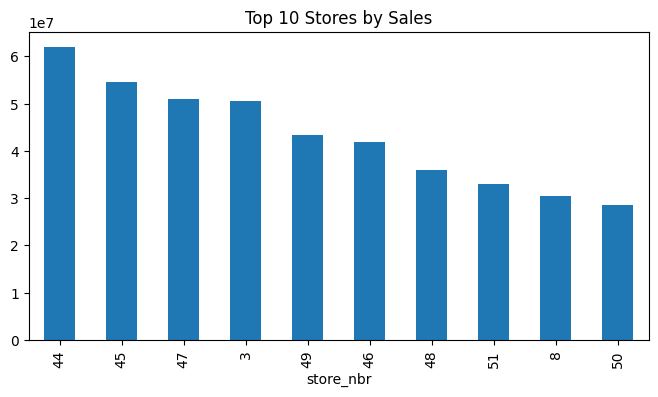

In [35]:
top_stores = train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
top_stores.plot(kind='bar')
plt.title("Top 10 Stores by Sales")
plt.show()


In [36]:
holidays['date'] = pd.to_datetime(holidays['date'])
holiday_sales = train.merge(holidays, on='date', how='left')
holiday_sales['is_holiday'] = holiday_sales['type'].notna()

holiday_sales.groupby('is_holiday')['sales'].mean()


is_holiday
False    352.159181
True     393.864762
Name: sales, dtype: float64

In [37]:
holiday_sales[['date', 'type', 'sales']].head(10)


,date,type,sales
0,2013-01-01,Holiday,0.0
1,2013-01-01,Holiday,0.0
2,2013-01-01,Holiday,0.0
3,2013-01-01,Holiday,0.0
4,2013-01-01,Holiday,0.0
5,2013-01-01,Holiday,0.0
6,2013-01-01,Holiday,0.0
7,2013-01-01,Holiday,0.0
8,2013-01-01,Holiday,0.0
9,2013-01-01,Holiday,0.0
